# Install & Import Requirements

In [ ]:
!pip install datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 12.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and p

In [17]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
import nltk
nltk.download('stopwords')
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import BertTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, TrainingArguments, Trainer
import evaluate
from datasets import Dataset
import torch
from torch.nn.functional import softmax


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
data_path = "" #@param {type:"string"}
text_column_name = "text" #@param {type:"string"}
label_column_name = "label" #@param {type:"string"}

model_name = "" #@param {type:"string"}
test_size = 0.2 #@param {type:"number"}
num_labels = 2 #@param {type:"number"}

# Read & Prepare Dataset

In [3]:
df = pd.read_csv(data_path)
df.tail()

,text,label
738,Model proses grafika komputer menggambarkan ba...,AI
739,Frame buffer adalah area memori dalam komputer...,AI
740,Grafika komputer berfokus pada pembuatan dan m...,AI
741,Model proses grafika komputer mengacu pada ser...,AI
742,Frame buffer adalah area penyimpanan dalam mem...,AI


In [ ]:
# cek data duplikat
df[df['text'].duplicated()]

,text,label
37,Metode yang akan saya gunakan dalam proyek ini...,Non AI
43,Metode yang dipilih yaitu SKKNI (Standar Komop...,Non AI
71,Grafika komputer adalah suatu bidang yang memp...,Non AI


In [ ]:
# cek data kosong
df.isnull().sum()

,0
text,0
label,0


In [4]:
# hapus data duplikat
df.drop_duplicates(subset=['text'], inplace=True)

In [5]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s-]', '', text)
    text = re.sub(r'-', ' ', text)
    return text

dictionary = {
    "dg": "dengan",
    "dgn": "dengan",
    "yg": "yang",
    "dpt": "dapat",
    "dlm": "dalam",
    "sdh": "sudah",
    "blm": "belum",
    "tp": "tapi",
    "tpi": "tapi"
}

def normalize_word(text, dictionary):
    words = text.split()
    words = [dictionary[word] if word in dictionary else word for word in words]
    return ' '.join(words)

df['text'] = df['text'].apply(normalize_text)
df['text'] = df['text'].apply(lambda x: normalize_word(x, dictionary))

df.head()

,text,label
0,statistik computer science machine learning da...,Non AI
1,stastik harus selalu ada dalam pembuatan data ...,Non AI
2,harus dikarenakan dalam teknologi data science...,Non AI
3,iya karena semuanya memiliki keterikatan diman...,Non AI
4,statistik computer science pembelajaran mesin ...,Non AI


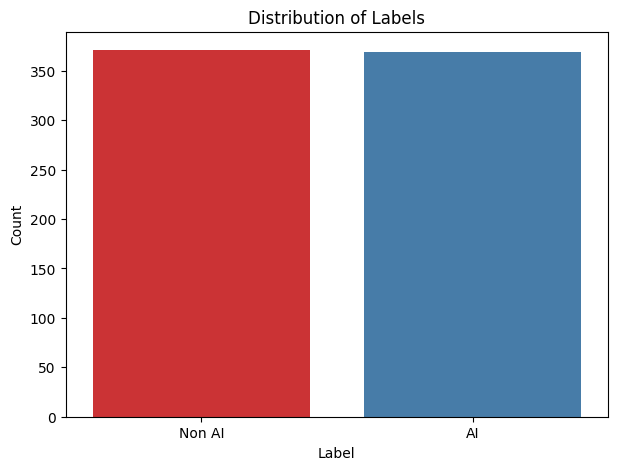

In [19]:
plt.figure(figsize=(7, 5))
sns.countplot(x='label', data=df, hue='label', palette='Set1', legend=False)
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

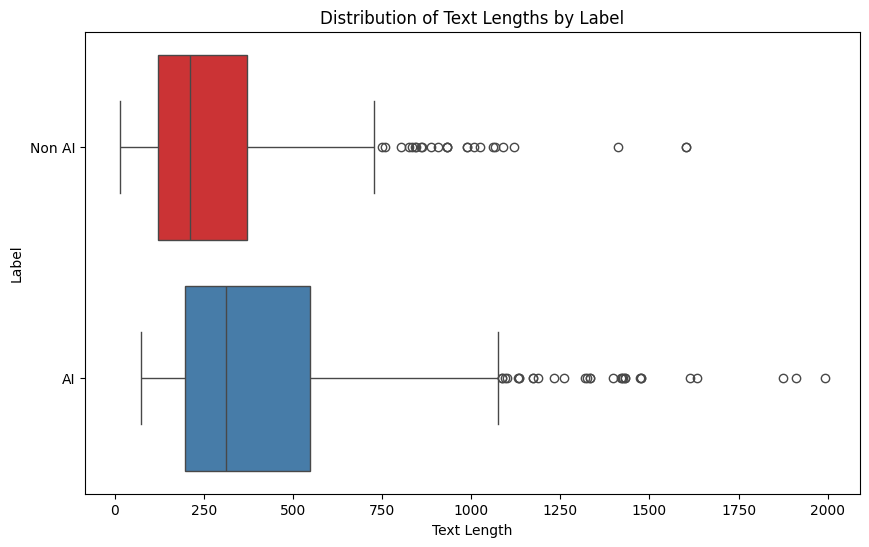

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='text_length', y='label', hue='label', palette='Set1', legend=False)
plt.title('Distribution of Text Lengths by Label')
plt.xlabel('Text Length')
plt.ylabel('Label')
plt.show()

In [18]:
df_wc = df.copy()

def remove_stopwords(text):
    stop_words = set(nltk.corpus.stopwords.words('indonesian'))
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

df_wc['text'] = df_wc['text'].apply(remove_stopwords)

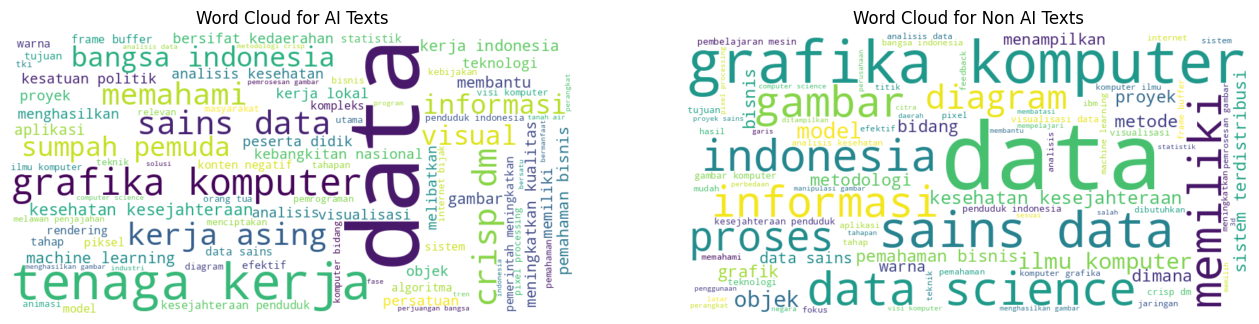

In [21]:
text_ai = ' '.join(df_wc[df_wc['label'] == 'AI']['text'])
text_non_ai = ' '.join(df_wc[df_wc['label'] == 'Non AI']['text'])

wordcloud_ai = WordCloud(width = 800, height = 400, background_color ='white', min_font_size = 10).generate(text_ai)
wordcloud_non_ai = WordCloud(width = 800, height = 400, background_color ='white', min_font_size = 10).generate(text_non_ai)

plt.figure(figsize = (16, 8))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_ai, interpolation = 'bilinear')
plt.axis('off')
plt.title('Word Cloud for AI Texts')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_non_ai, interpolation = 'bilinear')
plt.axis('off')
plt.title('Word Cloud for Non AI Texts')

plt.show()

# Label Encoder

In [ ]:
le = preprocessing.LabelEncoder()
le.fit(df[label_column_name].tolist())
df['label'] = le.transform(df[label_column_name].tolist())

df.head()

,text,label
0,statistik computer science machine learning da...,1
1,stastik harus selalu ada dalam pembuatan data ...,1
2,harus dikarenakan dalam teknologi data science...,1
3,iya karena semuanya memiliki keterikatan diman...,1
4,statistik computer science pembelajaran mesin ...,1


# Train/Test Split

In [ ]:
df_train, df_test = train_test_split(df, test_size = test_size, random_state=42)

# Convert to Huggingface Dataset

In [ ]:
train_dataset = Dataset.from_pandas(df_train)
test_dataset = Dataset.from_pandas(df_test)

# Tokenisasi

In [ ]:
tokenizer = BertTokenizer.from_pretrained(model_name)

def preprocess_function(examples):
  return tokenizer(examples['text'], truncation=True)

In [ ]:
tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_test = test_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/592 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Map:   0%|          | 0/148 [00:00<?, ? examples/s]

# Initialize Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at /content/drive/MyDrive/SKRIPSI/PERCOBAAN/MODEL and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Train Model

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis=-1)
  return metric.compute(predictions = predictions, references = labels)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
training_args = TrainingArguments(
    report_to='none',
    output_dir="./results",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.001,
    eval_strategy = "epoch",
    logging_strategy="epoch",
    warmup_ratio=0.01
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

<ipython-input-15-886e2e6b3d9f>:14: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.545200,0.331096,0.885135
2,0.278300,0.231274,0.918919
3,0.195200,0.189505,0.939189


TrainOutput(global_step=222, training_loss=0.3395752863841014, metrics={'train_runtime': 2611.3964, 'train_samples_per_second': 0.68, 'train_steps_per_second': 0.085, 'total_flos': 11161160337600.0, 'train_loss': 0.3395752863841014, 'epoch': 3.0})

# Evaluasi

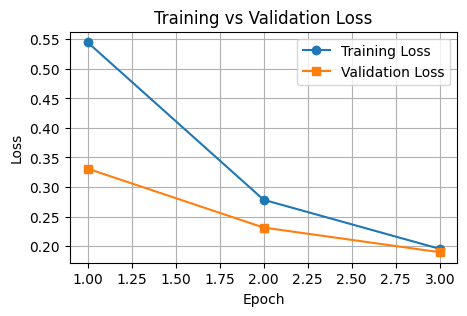

In [ ]:
# Grafik Training
log_history = trainer.state.log_history

epochs = []
train_loss = []
eval_loss = []

for log in log_history:
    if 'loss' in log and 'epoch' in log:
        train_loss.append(log['loss'])
        epochs.append(log['epoch'])
    if 'eval_loss' in log:
        eval_loss.append(log['eval_loss'])

plt.figure(figsize=(5,3))
plt.plot(epochs[:len(train_loss)], train_loss, marker='o', label='Training Loss')
plt.plot(epochs[-len(eval_loss):], eval_loss, marker='s', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Train Classification Report
preds = trainer.predict(tokenized_train)
preds = np.argmax(preds[:3][0],axis=1)
GT = df_train['label'].tolist()
print(classification_report(GT,preds))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       292
           1       0.96      0.98      0.97       300

    accuracy                           0.97       592
   macro avg       0.97      0.97      0.97       592
weighted avg       0.97      0.97      0.97       592



In [ ]:
# Test Classification Report
preds = trainer.predict(tokenized_test)
preds = np.argmax(preds[:3][0],axis=1)
GT = df_test['label'].tolist()
print(classification_report(GT,preds))

              precision    recall  f1-score   support

           0       0.99      0.90      0.94        77
           1       0.90      0.99      0.94        71

    accuracy                           0.94       148
   macro avg       0.94      0.94      0.94       148
weighted avg       0.94      0.94      0.94       148



In [ ]:
# Evaluasi Hasil
eval_results = trainer.evaluate()
print("Evaluasi Model:", eval_results)

Evaluasi Model: {'eval_loss': 0.18950524926185608, 'eval_accuracy': 0.9391891891891891, 'eval_runtime': 57.0407, 'eval_samples_per_second': 2.595, 'eval_steps_per_second': 0.333, 'epoch': 3.0}


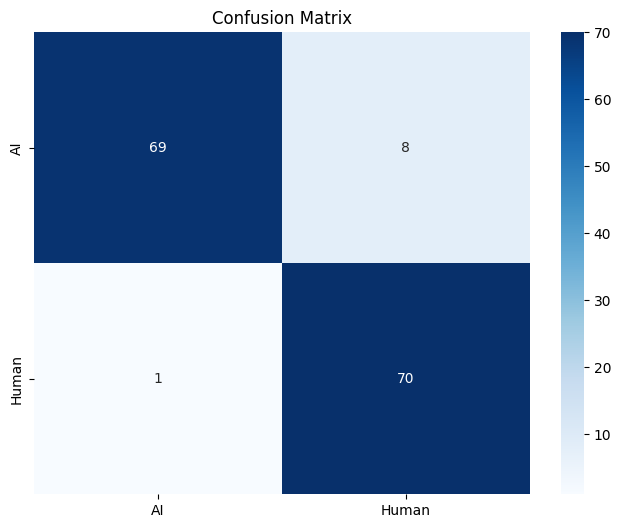

In [ ]:
# Confusion Matrix
preds = trainer.predict(tokenized_test)

logits = preds.predictions
predictions = np.argmax(logits, axis=-1)

labels = preds.label_ids

cm = confusion_matrix(labels, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["AI", "Human"], yticklabels=["AI", "Human"])

plt.title("Confusion Matrix")
plt.show()

# Save Model

In [ ]:
trainer.save_model("")
tokenizer.save_pretrained("")